Neural Network without using Tensorflow or Pytorch
==============

**Author:** *Aaron Bui*


This neural network contains 1 input layer, 1 hidden layer, 1 output layer. RELU (Rectified Linear Unit) and Loss (MSE - Mean Squared Error)

📐 ReLU Derivative (Used in Backprop)

![CleanShot 2025-06-25 at 12.26.31@2x.png](<attachment:CleanShot 2025-06-25 at 12.26.31@2x.png>)

In backpropagation, the gradient is a measure of how much the loss (error) changes with respect to each parameter (weight or bias) in the neural network. In simple terms, it tells you:

“If I slightly change this weight, how will the loss increase or decrease?”

The goal of training a neural network is to minimize the loss function (how wrong the model is). To do this, we use gradient descent, which relies on gradients to decide:

Which direction to move the weights

By how much (scaled by the learning rate)

🧠 Backpropagation Role
During backpropagation:

Forward pass: Compute the output and the loss

Backward pass:

Use the chain rule to compute gradients layer by layer:

![CleanShot 2025-06-25 at 12.31.58@2x.png](<attachment:CleanShot 2025-06-25 at 12.31.58@2x.png>)

where 𝑧
z is some intermediate output

These gradients are then used to update the weights:

![CleanShot 2025-06-25 at 12.32.39@2x.png](<attachment:CleanShot 2025-06-25 at 12.32.39@2x.png>)

where 𝜂
η is the learning rate

✅ Summary
Gradient = slope of loss with respect to each parameter

Backpropagation = algorithm to compute all gradients efficiently

Used in: gradient descent to optimize weights
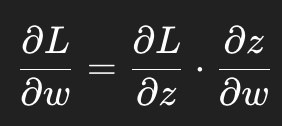
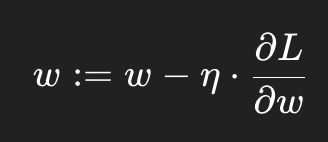

Install library

In [11]:
!pip3 install numpy

You should consider upgrading via the '/Library/Frameworks/Python.framework/Versions/3.10/bin/python3.10 -m pip install --upgrade pip' command.


In [12]:
import numpy as np

# --- Data ---
X = np.array([[1], [2], [3]], dtype=float)  # Inputs
Y = np.array([[3], [5], [7]], dtype=float)  # Targets (2x + 1)

# --- Initialize weights and biases ---
np.random.seed(42)
w1 = np.random.randn(1, 3)   # Input → hidden (1 input, 3 neurons)
b1 = np.zeros((1, 3))

w2 = np.random.randn(3, 1)   # Hidden → output (3 neurons, 1 output)
b2 = np.zeros((1, 1))

# --- Hyperparameters ---
lr = 0.01
epochs = 1000

# --- Activation functions ---
def relu(x):
    return np.maximum(0, x)

def relu_deriv(x):
    return (x > 0).astype(float)

# --- Training ---
for epoch in range(epochs):
    # Forward pass
    z1 = X @ w1 + b1        # Input to hidden
    a1 = relu(z1)           # Activation
    z2 = a1 @ w2 + b2       # Hidden to output
    y_pred = z2             # No activation in output layer

    # Loss (Mean Squared Error)
    loss = np.mean((y_pred - Y) ** 2)

    # Backward pass
    dL_dy = 2 * (y_pred - Y) / len(X)     # MSE derivative

    # Gradients for output layer
    dw2 = a1.T @ dL_dy
    db2 = np.sum(dL_dy, axis=0, keepdims=True)

    # Gradients for hidden layer
    da1 = dL_dy @ w2.T
    dz1 = da1 * relu_deriv(z1)

    dw1 = X.T @ dz1
    db1 = np.sum(dz1, axis=0, keepdims=True)

    # Update weights
    w2 -= lr * dw2
    b2 -= lr * db2
    w1 -= lr * dw1
    b1 -= lr * db1

    # Print loss occasionally
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: Loss = {loss:.4f}")

# --- Final Prediction ---
print("Final predictions:")
print(y_pred)


Epoch 0: Loss = 15.6638
Epoch 100: Loss = 0.0015
Epoch 200: Loss = 0.0002
Epoch 300: Loss = 0.0000
Epoch 400: Loss = 0.0000
Epoch 500: Loss = 0.0000
Epoch 600: Loss = 0.0000
Epoch 700: Loss = 0.0000
Epoch 800: Loss = 0.0000
Epoch 900: Loss = 0.0000
Final predictions:
[[2.99999419]
 [4.99999877]
 [7.00000335]]


---------------------------------------------------------------------------------------------------------------
***Building Neural Network using Tensorflow***

In [13]:
!pip3 install tensorflow

You should consider upgrading via the '/Library/Frameworks/Python.framework/Versions/3.10/bin/python3.10 -m pip install --upgrade pip' command.


In [ ]:
import tensorflow as tf
import numpy as np

# --- Data ---
X = np.array([[1], [2], [3]], dtype=float)
Y = np.array([[3], [5], [7]], dtype=float)

# --- Build the model ---
model = tf.keras.Sequential([
    tf.keras.layers.Dense(3, activation='relu', input_shape=(1,)),  # hidden layer with 3 neurons
    tf.keras.layers.Dense(1)  # output layer
])

# --- Compile the model ---
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
              loss='mean_squared_error')

# --- Train the model ---
model.fit(X, Y, epochs=1000, verbose=0)

# --- Predict ---
print("Final predictions:")
print(model.predict(X))

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


| Stretch/Untouched | ProbDistribution | Accuracy |
| --- | --- | --- |
| Stretched | Gaussian | .843 |

In [ ]:
import numpy as np

# Create a 3x2 table with the specified values
table = np.array([
    [1, 4.9999886],
    [2, 4.9999886],
    [3, 4.9999886]
], dtype=float)

print(table)

[[1.        4.9999886]
 [2.        4.9999886]
 [3.        4.9999886]]
